In [1]:
# PyTorch本体
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
# cuDNNの自動最適化（入力サイズが一定のとき畳み込みの高速化が期待できる）
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
import pytorch_tutorial as pt
import matplotlib.pyplot as plt
import time
import os
import tempfile
import json
from PIL import Image
from torchvision import datasets, models, transforms
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from pytorch_tutorial import setup_japanese_font

# COCO評価に必要なライブラリ群
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from collections import defaultdict


# 入力解像度が固定のときに最速のアルゴリズムを自動探索
cudnn.benchmark = True

# 対話モード（plt.show()なしでも描画が更新される）
plt.ion()   # interactive mode

日本語フォントを設定しました: Noto Sans CJK JP


In [2]:
# 実行デバイスの決定（GPUが使えるならCUDA、なければCPU）
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'use device: {device}')

# 物体検出＋セグメンテーション（Mask R-CNN）モデルの読み込み
# 事前学習済みのBackboneとFPNを持つマスクR-CNNをベースにする
num_classes = 2  # 背景を除いたクラス数: 本チュートリアルでは人物1クラス（+背景で内部は2）
model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

# バウンディングボックス分類器の入力量（ResNet+FPNからの特徴次元）を取得
in_features = model.roi_heads.box_predictor.cls_score.in_features
# 学習済みヘッドを差し替えて、クラス数を本タスクに合わせる
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# マスク予測器の入力量を取得して、こちらもクラス数を合わせる
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

# 事前に学習・保存しておいた重みを読み込み
model.load_state_dict(torch.load('./models/finetuning_model.pth', weights_only=True))
# モデルをデバイスへ転送
model.to(device)

use device: cuda


/work/kuribayashi/analytical_skill_tutorial/.venv/lib/python3.9/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [3]:
# データセット取得
class PennFudanDataset(torch.utils.data.Dataset):
    """
    Penn-Fudan Database for Pedestrian Detection and Segmentation用のカスタムデータセットクラス
    - 画像とマスク画像の読み込み
    - マスクから物体の境界ボックスを自動計算
    - 物体検出・セグメンテーション用のアノテーション情報の生成
    """
    
    def __init__(self, root, transforms):
        """
        データセットの初期化
        
        Args:
            root (str): データセットのルートディレクトリパス
                       root = /share/dtu_drone_tutorial/PennFudanPedの想定
            transforms (callable, optional): 画像とターゲットに適用する変換処理(前処理)
        """
        self.root = root
        self.transforms = transforms

        # ソートすることで、imageとmaskが順番に対応するようになる
        # PNGImagesディレクトリから画像ファイル名のリストを取得（ソート済み）
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        # PedMasksディレクトリからマスク画像ファイル名のリストを取得（ソート済み）
        self.mask = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        """
        指定されたインデックスのデータアイテムを取得
        
        Args:
            idx (int): データのインデックス
            
        Returns:
            tuple: (image, target) のタプル
                - image: PIL画像またはTensorに変換された画像
                - target: 物体検出用のアノテーション辞書
        """
        # 指定されたインデックスの画像とマスクのファイルパスを構築
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.mask[idx])

        # 元画像をRGBモードで読み込み（物体検出用）
        img = Image.open(img_path).convert("RGB")
        # マスク画像を読み込み（セグメンテーション用）
        mask = Image.open(mask_path)
        
        # マスク画像をnumpy配列に変換（後の処理のため）
        mask = np.array(mask)

        # マスク画像内のユニークなピクセル値を取得（各物体IDに対応）
        # 背景は通常0なので、1以降が物体のID
        obj_ids = np.unique(mask)
        obj_ids = obj_ids[1:]  # 背景（0）を除外し、物体IDのみを残す

        if len(obj_ids) == 0:
            print(f"No objects found in image {idx}")
            print("==============================")
        
        # 各物体IDに対応するバイナリマスクを作成
        # masks[i]は、i番目の物体の領域がTrueになる2次元配列
        masks = mask == obj_ids[:, None, None]

        # 検出された物体の数
        num_objs = len(obj_ids)
        boxes = []
        
        # 各物体に対して境界ボックス（バウンディングボックス）を計算
        for i in range(num_objs):
            # i番目の物体のピクセル位置を取得
            # 0でない領域の座標を取得
            pos = np.nonzero(masks[i])
            
            # 境界ボックスの座標を計算
            xmin = np.min(pos[1])  # 最小x座標
            xmax = np.max(pos[1])  # 最大x座標
            ymin = np.min(pos[0])  # 最小y座標
            ymax = np.max(pos[0])  # 最大y座標
            
            # [xmin, ymin, xmax, ymax] 形式で境界ボックスを保存
            boxes.append([xmin, ymin, xmax, ymax])

        # PyTorchのテンソルに変換（物体検出モデルで使用するため）
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        
        # ラベル：すべて1（人物クラス）に設定
        # 多クラス検出の場合は、ここで適切なクラスIDを設定
        labels = torch.ones((num_objs,), dtype=torch.int64)
        
        # マスクをテンソルに変換
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        # 画像ID（データセット内での一意識別子）
        image_id = torch.tensor([idx])
        
        # 各物体の面積を計算（境界ボックスから算出）
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        
        # iscrowd: 群衆フラグ（0=個別物体, 1=群衆）
        # Penn-Fudanデータセットでは個別の人物なので全て0
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        # 物体検出・セグメンテーション用のターゲット辞書を作成
        target = {}
        target["boxes"] = boxes        # 境界ボックス座標 [N, 4]
        target["labels"] = labels      # クラスラベル [N]
        target["masks"] = masks        # セグメンテーションマスク [N, H, W] (0, 1)
        target["image_id"] = image_id  # 画像ID
        target["area"] = area         # 物体面積 [N]
        target["iscrowd"] = iscrowd   # 群衆フラグ [N]

        # データ拡張やその他の変換処理を適用（指定されている場合）
        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        """
        データセットのサイズ（画像数）を返す
        
        Returns:
            int: データセット内の画像数
        """
        return len(self.imgs)

# データの前処理
def get_transform():
    # PIL画像をTensor化し、floatへ型変換（値域も[0,1]へ正規化）
    transforms = []
    transforms.append(pt.PILToTensor())
    transforms.append(pt.ConvertImageDtype(torch.float))
    # Composeで連結して一つの変換関数として返す
    return pt.Compose(transforms)


In [4]:
# 乱数シード固定（再現性）
torch.manual_seed(42)

# データセット作成（画像読み込み＋前処理）
dataset = PennFudanDataset('/share/dtu_drone_tutorial/PennFudanPed', get_transform())

# インデックスをシャッフルしてからランダムな順番でデータセットを取り出す
indices = torch.randperm(len(dataset)).tolist()

# 評価時間短縮のため、末尾の50枚のみを使用
dataset = torch.utils.data.Subset(dataset, indices[-50:])

# DataLoaderの作成
# - batch_size=1: 検出モデルは可変長出力のため1枚ずつ処理が安定
# - shuffle=False: 評価なので順序固定
# - num_workers=4: データ読み込みの並列度
# - collate_fn: 検出タスク用のバッチ整形関数（可変サイズ/可変個数のターゲットに対応）
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    collate_fn=pt.collate_fn
)


Starting evaluation...
Creating COCO format annotations...
Creating COCO format predictions...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.03s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.826
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.988
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.930
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.650
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.668
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.844
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.404
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= 

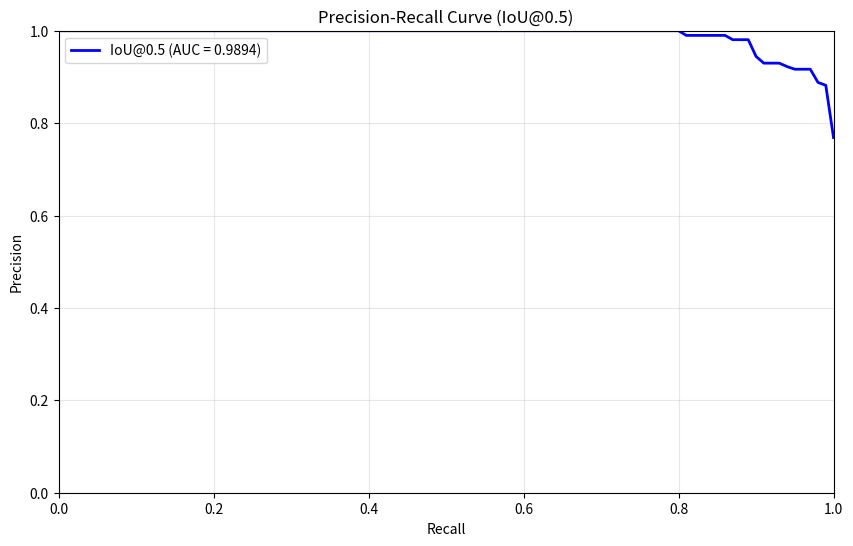

AUC for IoU@0.5: 0.9894


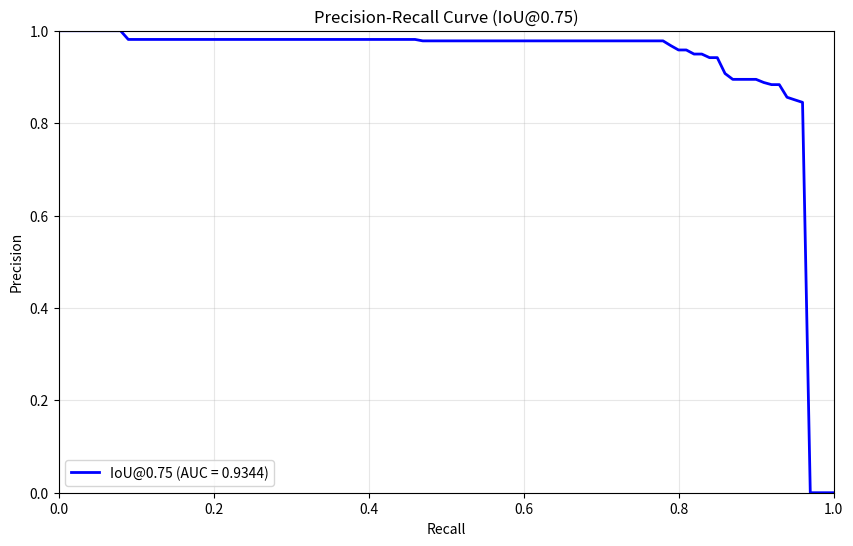

AUC for IoU@0.75: 0.9344


In [5]:
def create_coco_format_annotations(dataset):
    # データセットをCOCO形式のアノテーションに変換
    # - images: 画像のメタ情報（id, width, height, file_name）
    # - annotations: 物体ごとの注釈（image_id, category_id, bbox, area など）
    # - categories: カテゴリ定義（ここではpersonのみ）
    
    annotations = {
        "images": [],       # 画像情報の配列
        "annotations": [],  # アノテーションの配列
        "categories": [     # クラス定義（COCOフォーマット）今回は、人のみのクラス
            {"id": 1, "name": "person", "supercategory": "person"}
        ]
    }
    
    annotation_id = 1  # 各アノテーションに付与するユニークID
    
    for img_id in range(len(dataset)):
        # Subset(dataset, indices) なので dataset[img_id] は (Tensor画像, ターゲット辞書)
        img, target = dataset[img_id]

        # 画像サイズの取得（Tensor形状は [C, H, W]）
        height, width = int(img.shape[-2]), int(img.shape[-1])
            
        # 画像メタ情報の登録
        annotations["images"].append({
            "id": int(img_id),
            "width": width,
            "height": height,
            "file_name": f"image_{img_id}.jpg"  # 実ファイルは任意名でも可、評価には必須ではない
        })
        
        # ターゲットから必要な情報を取り出す
        boxes = target["boxes"]      # [N, 4] 形式（xmin, ymin, xmax, ymax）
        labels = target["labels"]    # [N]    物体クラスID
        areas = target["area"]       # [N]    面積
        iscrowds = target["iscrowd"] # [N]    群衆フラグ
        
        for i in range(len(boxes)):
            box = boxes[i].tolist()
            # COCO形式のbboxは [x, y, width, height]
            coco_box = [
                float(box[0]),
                float(box[1]),
                float(box[2] - box[0]), # x方向の計算
                float(box[3] - box[1])  # y方向の計算
            ]
            
            # 1物体＝1アノテーションとして追加
            annotations["annotations"].append({
                "id": int(annotation_id),
                "image_id": int(img_id),
                "category_id": int(labels[i].item()),
                "bbox": coco_box,
                "area": float(areas[i].item()),
                "iscrowd": int(iscrowds[i].item())  
            })
            annotation_id += 1
    
    return annotations


def create_coco_format_predictions(model, data_loader, device):
    # モデルの予測結果をCOCO形式に変換
    # - 画像IDと1:1対応する必要がある
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for img_id, (images, _) in enumerate(data_loader):
            # バッチ内の各画像をデバイスへ転送
            images = list(img.to(device) for img in images)
            outputs = model(images)
            
            # outputsはバッチ長のリストで、各要素は辞書（boxes, labels, scores など）
            for output in outputs:
                boxes = output["boxes"].cpu().numpy()
                scores = output["scores"].cpu().numpy()
                labels = output["labels"].cpu().numpy()
                
                for i in range(len(boxes)):
                    box = boxes[i]
                    # COCO形式: [x, y, width, height]
                    coco_box = [
                        float(box[0]),
                        float(box[1]),
                        float(box[2] - box[0]),
                        float(box[3] - box[1])
                    ]
                    
                    predictions.append({
                        "image_id": int(img_id),
                        "category_id": int(labels[i]),
                        "bbox": coco_box,
                        "score": float(scores[i])
                    })
    
    return predictions


def evaluate_with_pycocotools(model, data_loader, dataset, device):
    #   1) 正解データをCOCO形式へ変換
    #   2) 予測をCOCO形式へ変換
    #   3) 一時JSONに保存してCOCOevalで読み込み
    #   4) IoU閾値ごとに評価->評価値の計算
    
    # 正解データをcoco形式に変換する
    print("Creating COCO format annotations...")
    gt_annotations = create_coco_format_annotations(dataset)
    
    # 予測結果をcoco形式に変換する
    print("Creating COCO format predictions...")
    predictions = create_coco_format_predictions(model, data_loader, device)
    
    # pycocotoolsはJSONファイルから読み込む前提のため一旦一時ファイルに書き出す
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        json.dump(gt_annotations, f)
        gt_file = f.name
    
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        json.dump(predictions, f)
        pred_file = f.name
    
    try:
        # COCO評価の実行
        # どちらもCOCOクラスのインスタンスが返り値となっている
        # アノテーションファイル(json)を引数に渡して読み込む
        coco_gt = COCO(gt_file)
        # 予測結果ファイル(json)を引数に渡して読み込む
        coco_dt = coco_gt.loadRes(pred_file)
        
        # mAP@x　の計算
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        coco_eval.evaluate(); coco_eval.accumulate(); coco_eval.summarize()
        map_all = coco_eval.stats[0]
        map_50 = coco_eval.stats[1]
        map_75 = coco_eval.stats[2]
        
        print(f"\n=== 評価結果 ===")
        print(f"mAP@0.5:0.95: {map_all:.4f}")
        print(f"mAP@0.5: {map_50:.4f}")
        print(f"mAP@0.75: {map_75:.4f}")
        
        # PR曲線とAUCの計算
        plot_precision_recall_curve(coco_eval, iou_threshold=0.5)
        plot_precision_recall_curve(coco_eval, iou_threshold=0.75)
        
        return {
            'mAP@0.5': map_50,
            'mAP@0.75': map_75,
            'mAP@0.5:0.95': map_all,
            'coco_eval': coco_eval
        }
    finally:
        # 一時ファイルを削除
        os.unlink(gt_file)
        os.unlink(pred_file)


def plot_precision_recall_curve(coco_eval, iou_threshold=0.5):
    # PR曲線をプロットし、AUCを計算
    # - coco_eval.eval['precision'] の形状は [T, R, K, A, M]
    # T: IoUしきい値数, R: Recallしきい値数, K: カテゴリ数, A: 面積レンジ(all, small, medium, large), M: 最大検出数(1, 10, 100)
    # PR値が定義されていない場合は、-1となるため、その値を除外してAUCを計算する必要がある
    iou_thrs = coco_eval.params.iouThrs
    rec_thrs = coco_eval.params.recThrs

    # 指定した閾値のインデックスを探索(IoU=thresholdのPR値群を取得)
    t = int(np.where(iou_thrs==iou_threshold)[0][0])
    k = 0
    a = coco_eval.params.areaRngLbl.index('all') # とりあえずALLで考えてみる
    
    # Precision-Recallデータの取得
    p = coco_eval.eval['precision'][t, :, k, a, -1]
    mask = p > -1  # 未定義の値を除外

    # AUC計算（台形公式）
    auc = np.trapz(p[mask], rec_thrs[mask])
    
    # PR曲線のプロット
    plt.figure(figsize=(10, 6))
    plt.plot(rec_thrs[mask], p[mask], 'b-', linewidth=2, label=f'IoU@{iou_threshold} (AUC = {auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve (IoU@{iou_threshold})')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.show()
    
    print(f"AUC for IoU@{iou_threshold}: {auc:.4f}")
    
    return auc

# 評価実行
print("Starting evaluation...")
results = evaluate_with_pycocotools(model, data_loader, dataset, device)


=== 評価結果 ===
mAP@0.5: 0.9884
mAP@0.75: 0.9301
mAP@0.5:0.95: 0.8261

Starting segmentation evaluation...
Creating COCO format (segm) annotations...
Creating COCO format (segm) predictions...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=   all | maxDets=100 ] = 0.989
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= small | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.50:0.50 | area=medium | maxDets=100 ] = 0.955
 Average Precision  (AP) @[ IoU=0.50:0.50 | area= large | maxDets=100 ] = 0.998
 Average Recall     (AR) @[ IoU=0.50:0.50 | area=   all | maxDets=  1 ] = 0.442
 Average Recall     (

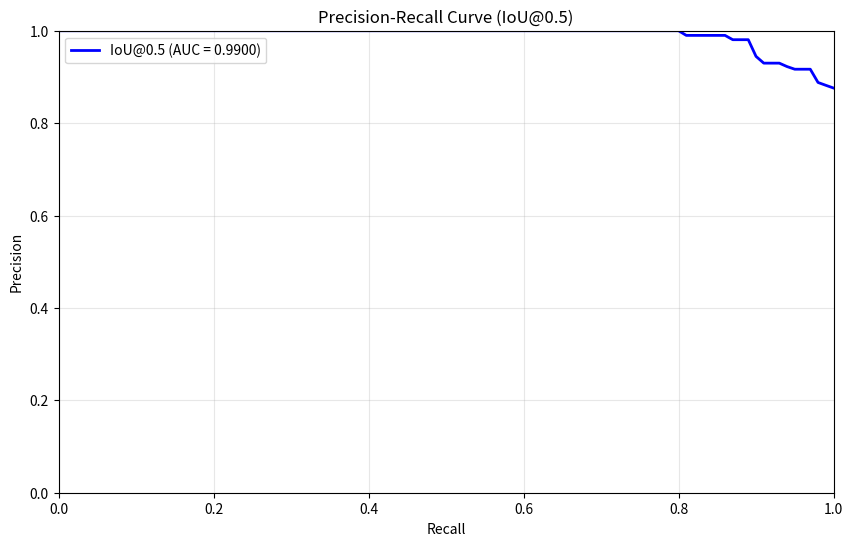

AUC for IoU@0.5: 0.9900


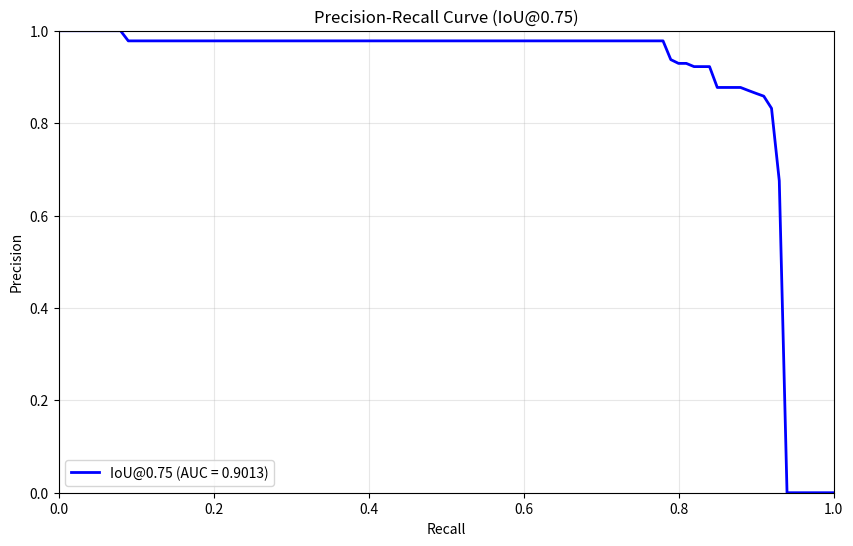

AUC for IoU@0.75: 0.9013


In [8]:
# === セグメンテーション（マスク）評価 ===
# pycocotools では、マスクはRLE形式（Run-Length Encoding）で扱うのが標準
from pycocotools import mask as maskUtils


def _encode_binary_mask_to_rle(binary_mask: np.ndarray):
    """
    2値マスク(H, W)をCOCO互換のRLE辞書に変換
    - binary_mask: 0/1 の numpy.ndarray (H, W)
    - 戻り値: {"size": [H, W], "counts": <ascii str>} の辞書
    """
    rle = maskUtils.encode(np.asfortranarray(binary_mask.astype(np.uint8)))
    # json.dump可能なようにbytes→ascii文字列へ
    rle["counts"] = rle["counts"].decode("ascii")
    return rle


def create_coco_format_annotations_segm(dataset):
    """
    データセットのGTをCOCO形式（セグメンテーション用：RLE）へ変換
    - annotations[].segmentation にRLEを格納
    - area はマスクの画素数を使用
    - bbox も保持（COCO仕様上、bbox有りのほうが無難）
    """
    annotations = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": 1, "name": "person", "supercategory": "person"}
        ]
    }

    annotation_id = 1

    for img_id in range(len(dataset)):
        img, target = dataset[img_id]
        height, width = int(img.shape[-2]), int(img.shape[-1])

        annotations["images"].append({
            "id": int(img_id),
            "width": width,
            "height": height,
            "file_name": f"image_{img_id}.jpg",
        })

        boxes = target["boxes"]        # [N, 4] (xmin, ymin, xmax, ymax)
        labels = target["labels"]      # [N]
        masks = target["masks"]        # [N, H, W] (0/1)
        iscrowds = target["iscrowd"]   # [N]

        for i in range(len(boxes)):
            box = boxes[i].tolist()
            coco_box = [
                float(box[0]),
                float(box[1]),
                float(box[2] - box[0]),
                float(box[3] - box[1]),
            ]

            binary_mask = masks[i].cpu().numpy().astype(np.uint8)
            rle = _encode_binary_mask_to_rle(binary_mask)
            area = float(binary_mask.sum())

            annotations["annotations"].append({
                "id": int(annotation_id),
                "image_id": int(img_id),
                "category_id": int(labels[i].item()),
                "bbox": coco_box,
                "area": area,
                "iscrowd": int(iscrowds[i].item()),
                "segmentation": rle,
            })
            annotation_id += 1

    return annotations


def create_coco_format_predictions_segm(model, data_loader, device, mask_threshold: float = 0.5):
    """
    モデルの予測(マスク付き)をCOCO形式（RLE）へ変換
    - Mask R-CNNの出力 'masks' (N, 1, H, W) を閾値で2値化→RLE
    - 'bbox', 'score', 'category_id', 'image_id' も付与
    """
    model.eval()
    predictions = []

    with torch.no_grad():
        for img_id, (images, _) in enumerate(data_loader):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for output in outputs:
                boxes = output["boxes"].detach().cpu().numpy()
                scores = output["scores"].detach().cpu().numpy()
                labels = output["labels"].detach().cpu().numpy()
                masks = output.get("masks", None)  # (N, 1, H, W)

                if masks is None:
                    continue

                masks = masks.detach().cpu().numpy()  # float(0..1)
                masks = masks[:, 0, :, :]             # (N, H, W)

                for i in range(len(boxes)):
                    box = boxes[i]
                    coco_box = [
                        float(box[0]),
                        float(box[1]),
                        float(box[2] - box[0]),
                        float(box[3] - box[1]),
                    ]

                    # 閾値で2値化してRLE化
                    binary_mask = (masks[i] >= mask_threshold).astype(np.uint8)
                    rle = _encode_binary_mask_to_rle(binary_mask)

                    predictions.append({
                        "image_id": int(img_id),
                        "category_id": int(labels[i]),
                        "bbox": coco_box,
                        "score": float(scores[i]),
                        "segmentation": rle,
                    })

    return predictions


def evaluate_segmentation_with_pycocotools(model, data_loader, dataset, device, mask_threshold: float = 0.5):
    """
    pycocotoolsを用いたセグメンテーション評価（'segm'）
    - GT/予測ともにRLE形式のマスクを含むCOCO JSONへ変換
    - IoU@0.5, @0.75, @0.5:0.95 を出力
    - PR曲線とAUCも描画
    """
    print("Creating COCO format (segm) annotations...")
    gt_annotations = create_coco_format_annotations_segm(dataset)

    print("Creating COCO format (segm) predictions...")
    predictions = create_coco_format_predictions_segm(model, data_loader, device, mask_threshold)

    # 一時ファイルに保存
    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(gt_annotations, f)
        gt_file = f.name

    with tempfile.NamedTemporaryFile(mode="w", suffix=".json", delete=False) as f:
        json.dump(predictions, f)
        pred_file = f.name

    try:
        coco_gt = COCO(gt_file)
        coco_dt = coco_gt.loadRes(pred_file)

        # IoU=0.5
        coco_eval_50 = COCOeval(coco_gt, coco_dt, iouType='segm')
        coco_eval_50.params.iouThrs = [0.5]
        coco_eval_50.evaluate(); coco_eval_50.accumulate(); coco_eval_50.summarize()
        map_50 = coco_eval_50.stats[0]

        # IoU=0.75
        coco_eval_75 = COCOeval(coco_gt, coco_dt, iouType='segm')
        coco_eval_75.params.iouThrs = [0.75]
        coco_eval_75.evaluate(); coco_eval_75.accumulate(); coco_eval_75.summarize()
        map_75 = coco_eval_75.stats[0]

        # IoU=0.5:0.95 (全体)
        coco_eval_all = COCOeval(coco_gt, coco_dt, iouType='segm')
        coco_eval_all.evaluate(); coco_eval_all.accumulate(); coco_eval_all.summarize()
        map_all = coco_eval_all.stats[0]

        print("\n=== セグメンテーション評価結果 ===")
        print(f"mAP@0.5 (segm): {map_50:.4f}")
        print(f"mAP@0.75 (segm): {map_75:.4f}")
        print(f"mAP@0.5:0.95 (segm): {map_all:.4f}")

        # PR曲線（segm）
        plot_precision_recall_curve(coco_eval_50, iou_threshold=0.5)
        plot_precision_recall_curve(coco_eval_75, iou_threshold=0.75)

        return {
            "mAP@0.5(segm)": map_50,
            "mAP@0.75(segm)": map_75,
            "mAP@0.5:0.95(segm)": map_all,
            "coco_eval_50(segm)": coco_eval_50,
            "coco_eval_75(segm)": coco_eval_75,
        }
    finally:
        os.unlink(gt_file)
        os.unlink(pred_file)


# 実行（セグメンテーション評価）
print("Starting segmentation evaluation...")
segm_results = evaluate_segmentation_with_pycocotools(model, data_loader, dataset, device, mask_threshold=0.5)

